# Notebook 06: Publication Visualizations Suite & Graphical Exhibits
## Code-Driven High-Resolution Visual Exhibits for the F1 Indian Grand Prix Case Study

### Analytical Objectives:
1. Generate all 8 master publication charts on the fly using Python, Matplotlib, and Seaborn.
2. Apply publication-grade typography, consistent palettes, error-free scaling, and rich annotations.
3. Map every graphic directly to its corresponding research question and findings section.
4. Export high-resolution (300 DPI) artifacts to `reports/figures/` for report integration.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Ensure working directory is repository root when running inside notebooks/
if not os.path.exists('data') and os.path.exists('../data'):
    os.chdir('..')

# Visual formatting defaults
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

os.makedirs('reports/figures', exist_ok=True)

# Load data layers
f1_clean = pd.read_csv('data/processed/f1_races_clean.csv')
f1_eng = pd.read_csv('data/engineered/f1_races_engineered.csv')
india_clean = pd.read_csv('data/processed/india_gp_clean.csv')
india_eng = pd.read_csv('data/engineered/india_gp_engineered.csv')
india_ctx = pd.read_csv('data/processed/india_gp_context_clean.csv')

print(f"[OK] Loaded clean baseline ({len(f1_clean)} races) and India case study data.")

[OK] Loaded clean baseline (198 races) and India case study data.


---
### Exhibit 1: Global Sunday Race-Day Attendance Distribution & Indian GP Overlays (RQ1, RQ2)
**Analytical Question:** Where did the three Indian GP editions rank within the global F1 Sunday attendance distribution (2010–2019)?

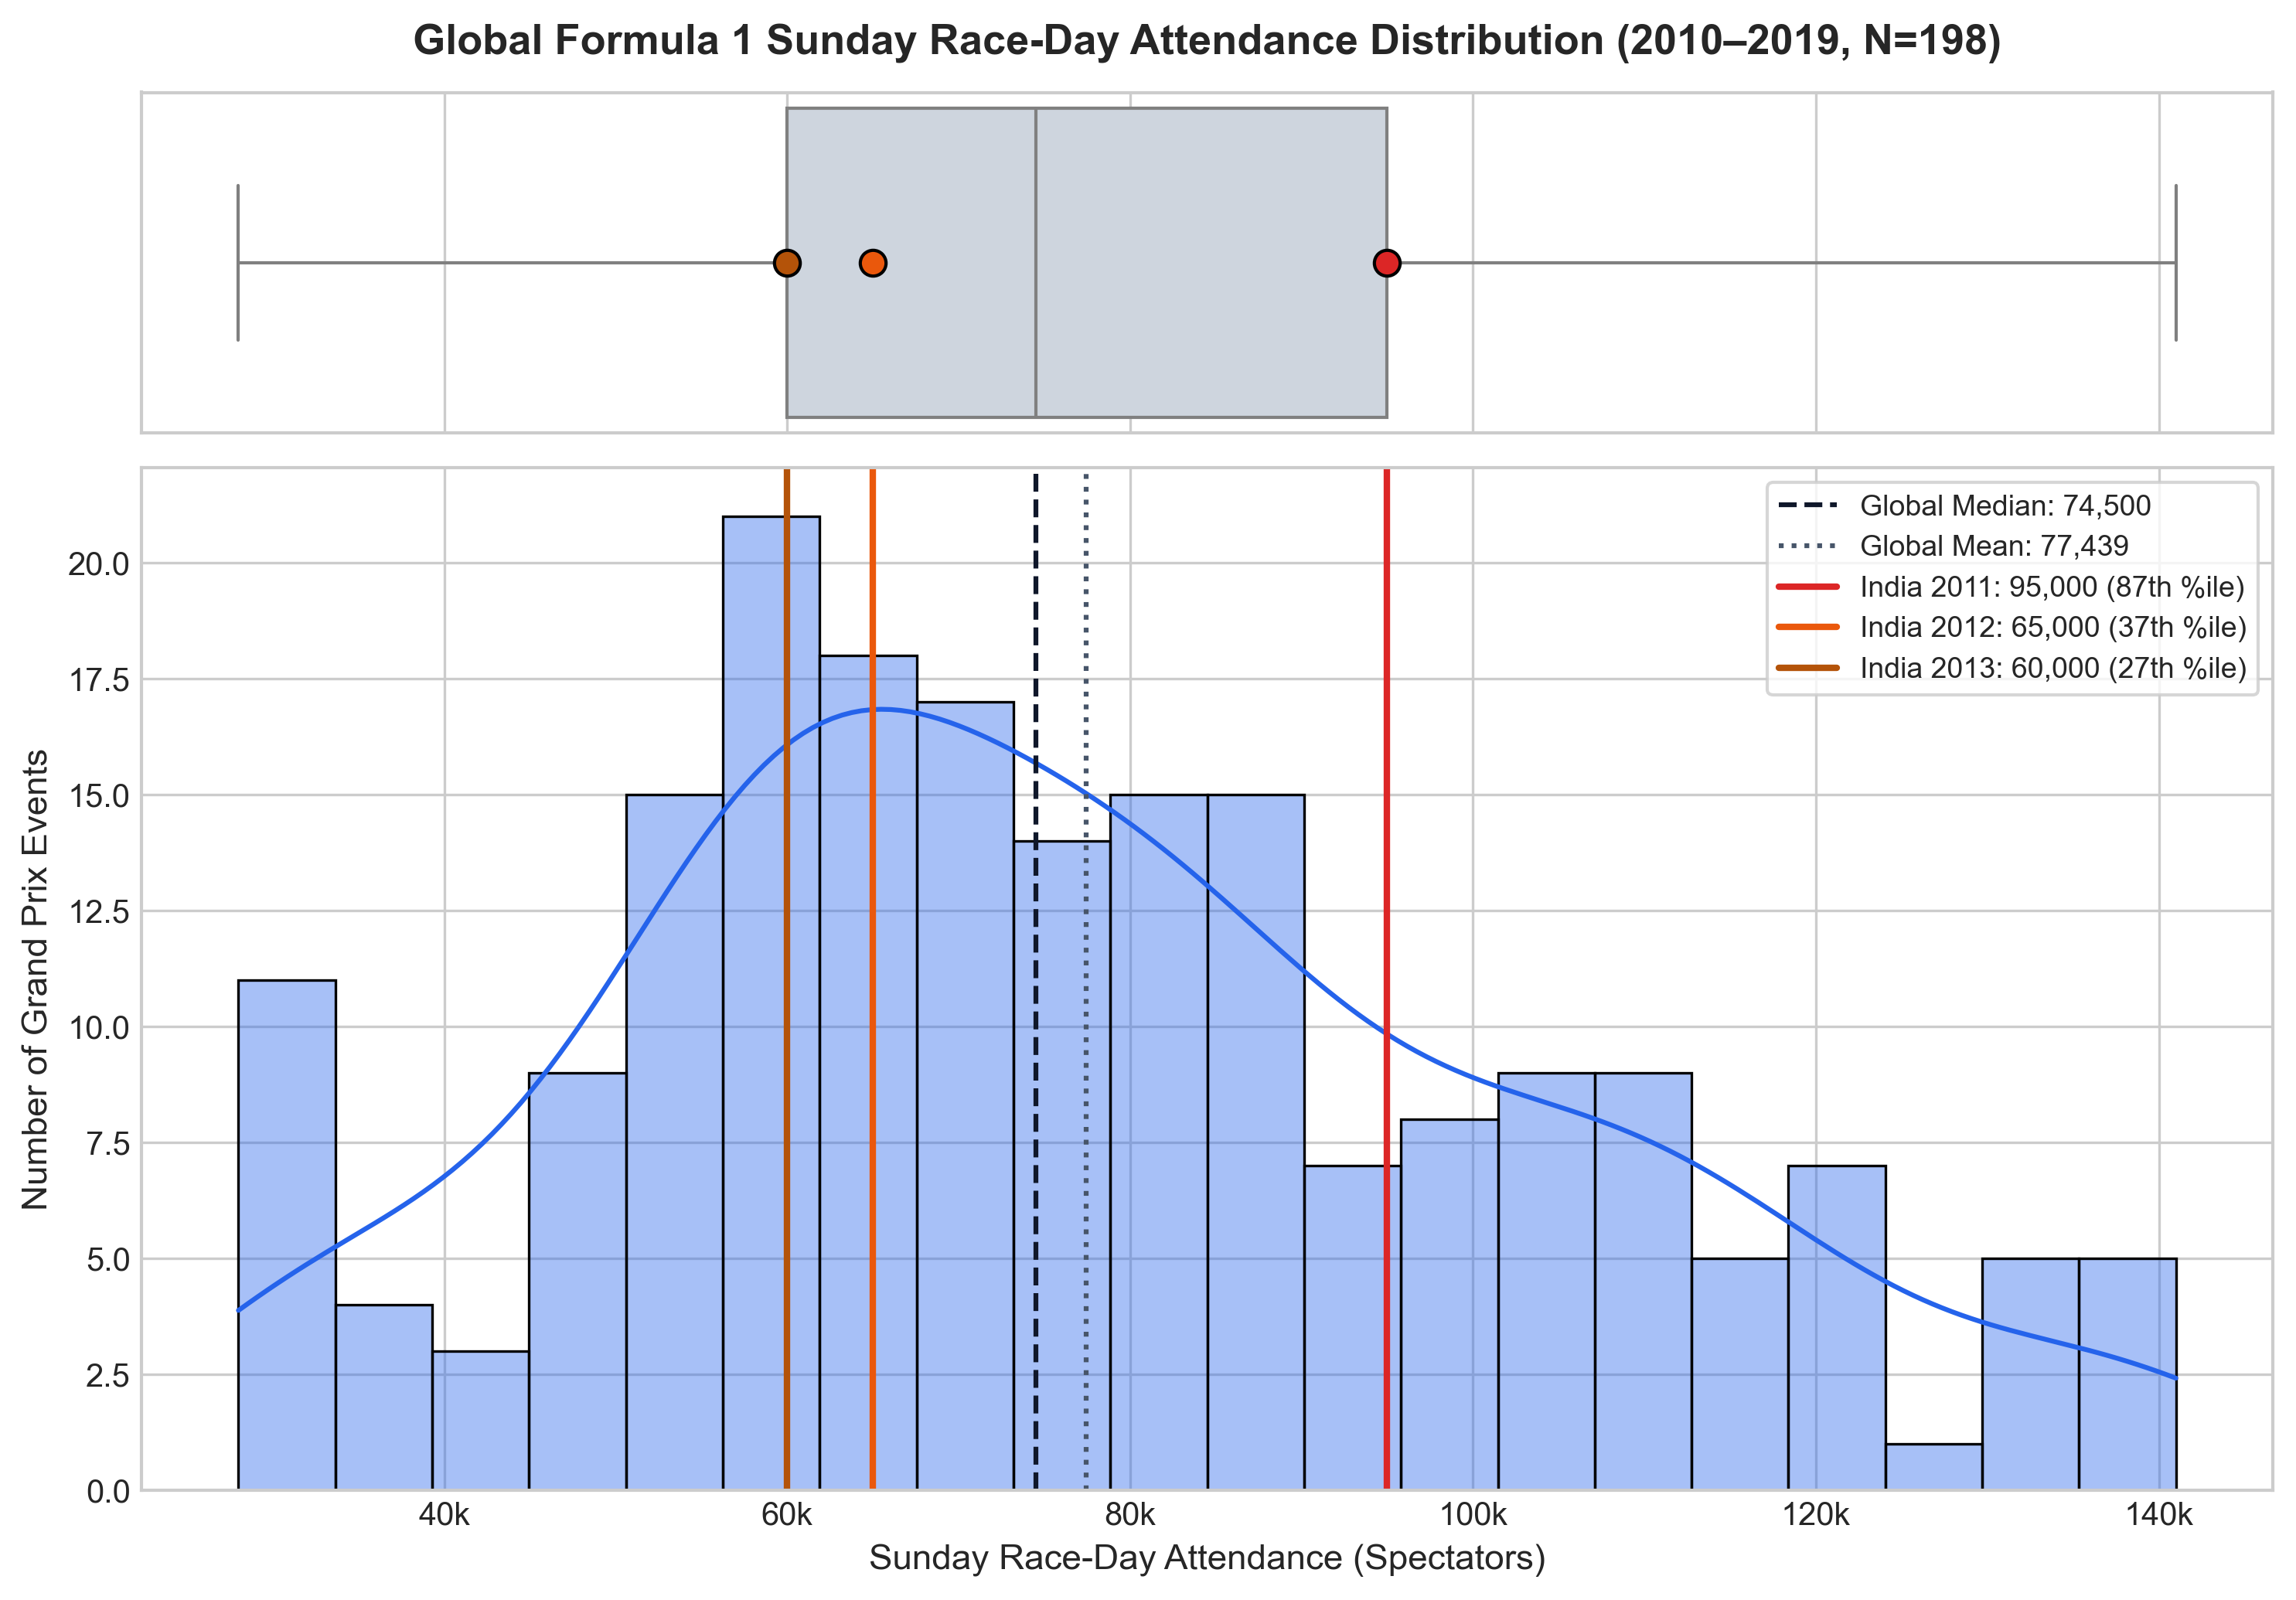

In [4]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [0.25, 0.75]})

# Boxplot
sns.boxplot(x=f1_clean['attendance_race_day'], ax=ax_box, color='#cbd5e1', fliersize=3)
ax_box.set(xlabel='')
ax_box.set_title('Global Formula 1 Sunday Race-Day Attendance Distribution (2010–2019, N=198)', fontweight='bold', pad=12)

# Histogram + KDE
sns.histplot(f1_clean['attendance_race_day'], kde=True, ax=ax_hist, color='#2563eb', bins=20, alpha=0.4, edgecolor='black', linewidth=0.8)

# Baseline metrics
median_att = f1_clean['attendance_race_day'].median()
mean_att = f1_clean['attendance_race_day'].mean()
ax_hist.axvline(median_att, color='#0f172a', linestyle='--', linewidth=1.5, label=f'Global Median: {median_att:,.0f}')
ax_hist.axvline(mean_att, color='#475569', linestyle=':', linewidth=1.5, label=f'Global Mean: {mean_att:,.0f}')

# Overlay India points
india_points = [
    (95000, 2011, '#dc2626', 'India 2011: 95,000 (87th %ile)'),
    (65000, 2012, '#ea580c', 'India 2012: 65,000 (37th %ile)'),
    (60000, 2013, '#b45309', 'India 2013: 60,000 (27th %ile)')
]
for val, year, col, lab in india_points:
    ax_hist.axvline(val, color=col, linestyle='-', linewidth=2, label=lab)
    ax_box.plot(val, 0, marker='o', markersize=8, color=col, markeredgecolor='black')
    
ax_hist.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))
ax_hist.set_xlabel('Sunday Race-Day Attendance (Spectators)')
ax_hist.set_ylabel('Number of Grand Prix Events')
ax_hist.legend(frameon=True, facecolor='white', loc='upper right', fontsize=9)
plt.tight_layout()
fig.savefig('reports/figures/fig1_attendance_distribution_with_india.png')
plt.show()

---
### Exhibit 2: Indian Grand Prix Gate Attendance Decay Trajectory (RQ1)
**Analytical Question:** How did Sunday race-day and 3-day weekend gate counts evolve from 2011 to 2013 at Buddh International Circuit?

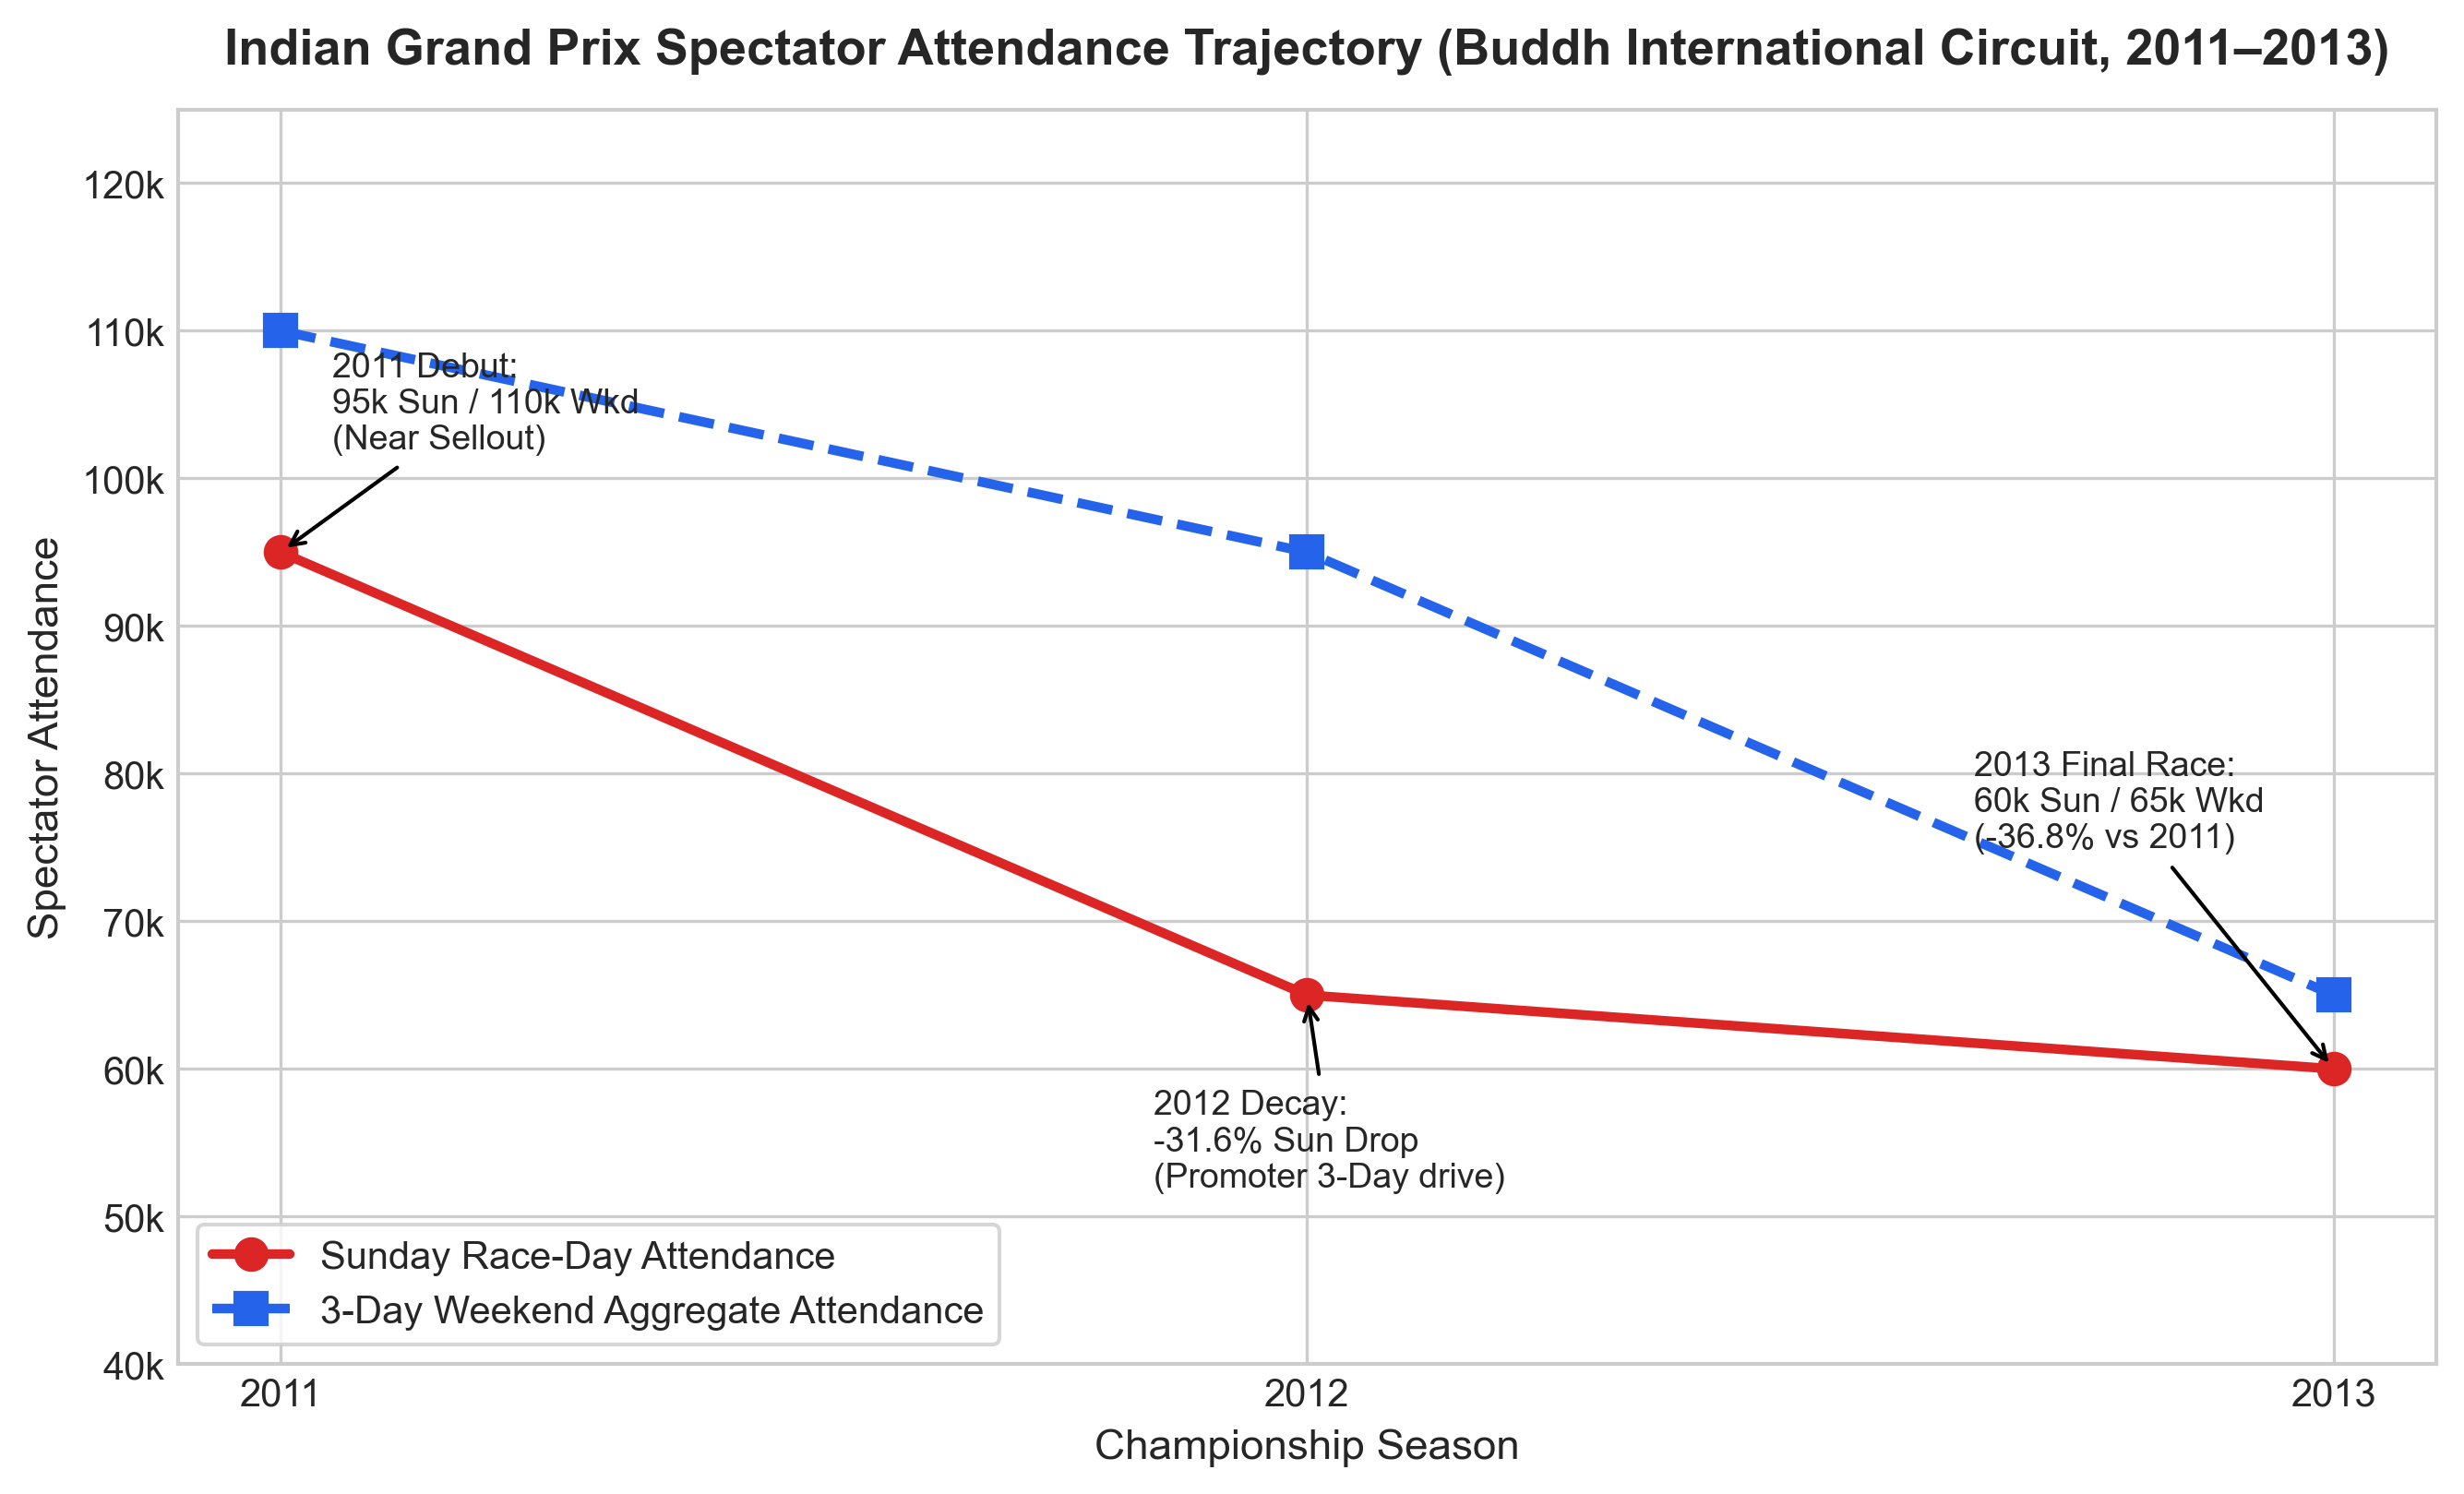

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
years = [2011, 2012, 2013]
sun_att = [95000, 65000, 60000]
wkd_att = [110000, 95000, 65000]

ax.plot(years, sun_att, marker='o', linewidth=2.5, markersize=8, color='#dc2626', label='Sunday Race-Day Attendance')
ax.plot(years, wkd_att, marker='s', linewidth=2.5, markersize=8, color='#2563eb', linestyle='--', label='3-Day Weekend Aggregate Attendance')

# Annotations
ax.annotate('2011 Debut:\n95k Sun / 110k Wkd\n(Near Sellout)', xy=(2011, 95000), xytext=(2011.05, 102000),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1), fontsize=9)
ax.annotate('2012 Decay:\n-31.6% Sun Drop\n(Promoter 3-Day drive)', xy=(2012, 65000), xytext=(2011.85, 52000),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1), fontsize=9)
ax.annotate('2013 Final Race:\n60k Sun / 65k Wkd\n(-36.8% vs 2011)', xy=(2013, 60000), xytext=(2012.65, 75000),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1), fontsize=9)
            
ax.set_xticks(years)
ax.set_ylim(40000, 125000)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))
ax.set_xlabel('Championship Season')
ax.set_ylabel('Spectator Attendance')
ax.set_title('Indian Grand Prix Spectator Attendance Trajectory (Buddh International Circuit, 2011–2013)', fontweight='bold', pad=12)
ax.legend(loc='lower left', frameon=True, facecolor='white')
plt.tight_layout()
fig.savefig('reports/figures/fig2_indian_gp_decay_curve.png')
plt.show()

---
### Exhibit 3: Regional Continental Attendance Benchmarks (RQ2)
**Analytical Question:** How did Asian Grand Prix events compare with European, American, and Oceanian rounds?

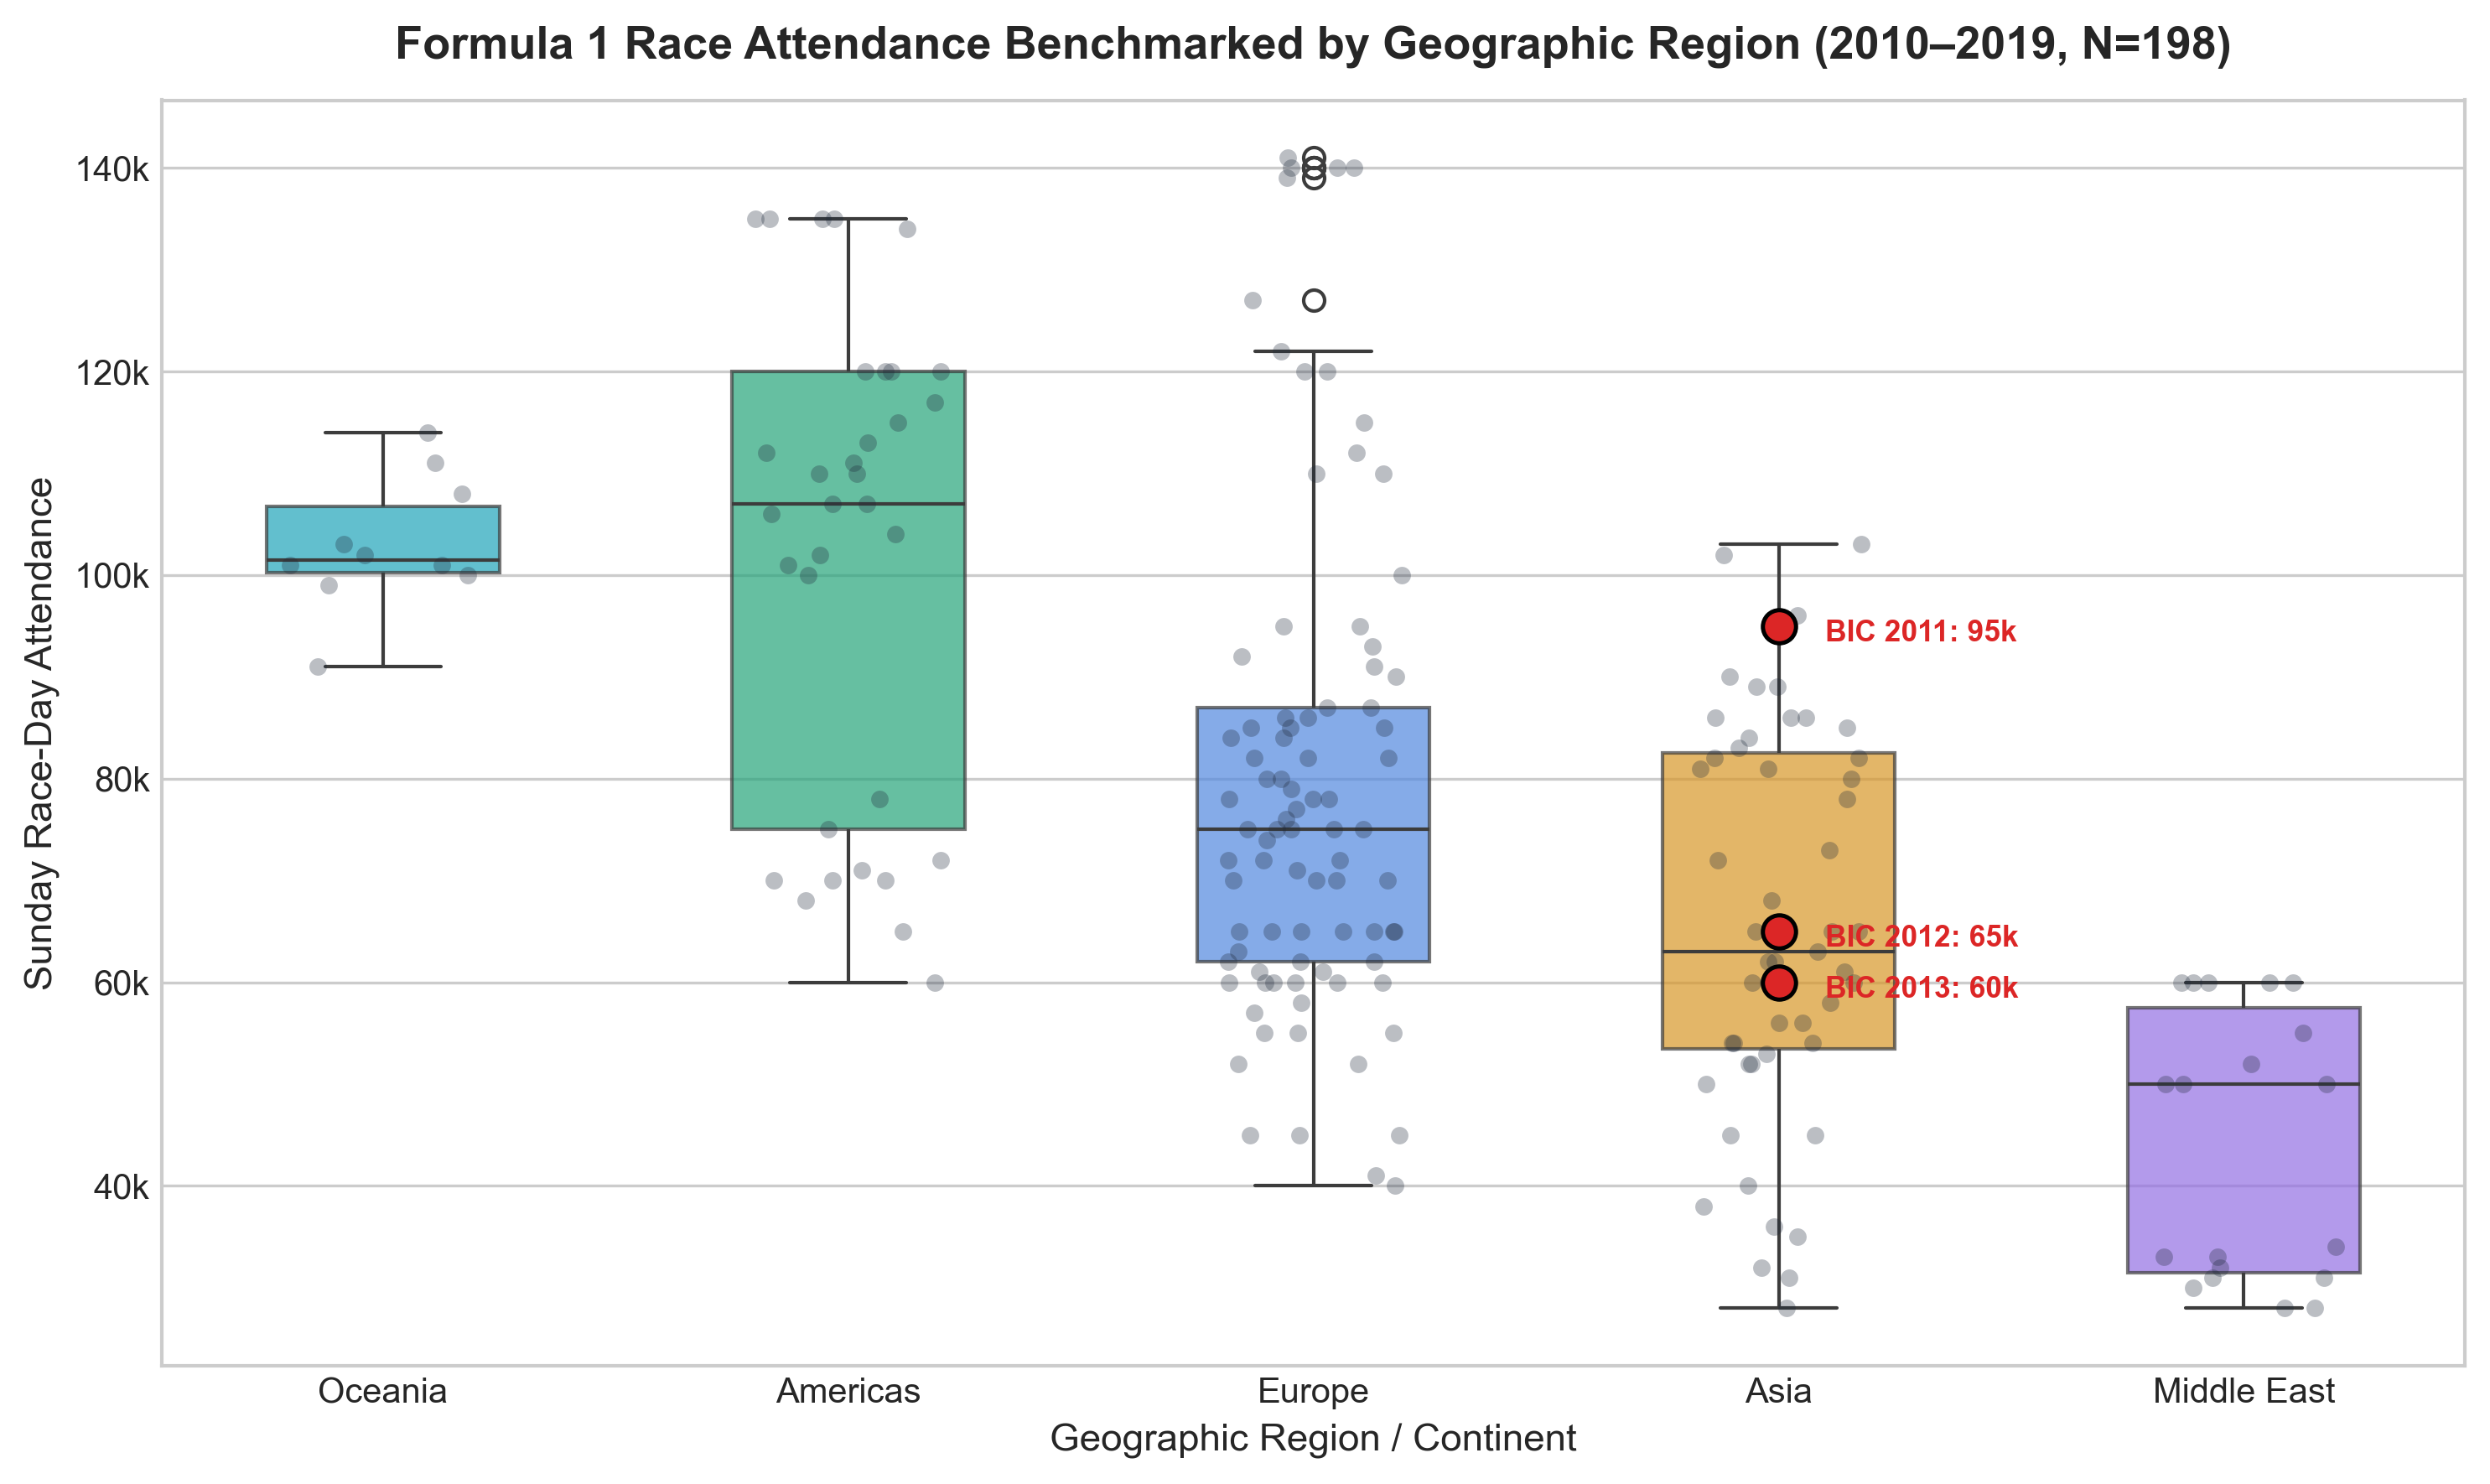

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
order = ['Oceania', 'Americas', 'Europe', 'Asia', 'Middle East']
palette = {'Europe': '#3b82f6', 'Americas': '#10b981', 'Asia': '#f59e0b', 'Middle East': '#8b5cf6', 'Oceania': '#06b6d4'}

sns.boxplot(x='continent', y='attendance_race_day', hue='continent', data=f1_clean, order=order, palette=palette, ax=ax, width=0.5, boxprops=dict(alpha=0.7), legend=False)
sns.stripplot(x='continent', y='attendance_race_day', data=f1_clean, order=order, color='#1e293b', alpha=0.3, jitter=0.2, size=5, ax=ax)

# Highlight Buddh Points in Asia
buddh_points = f1_clean[f1_clean['circuit_id'] == 'buddh']
for _, r in buddh_points.iterrows():
    ax.scatter(3, r['attendance_race_day'], color='#dc2626', s=90, zorder=5, edgecolors='black', linewidth=1.2)
    ax.text(3.1, r['attendance_race_day'] - 1500, f"BIC {r['season']}: {int(r['attendance_race_day']/1000)}k", color='#dc2626', fontweight='bold', fontsize=8.5)
    
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))
ax.set_xlabel('Geographic Region / Continent')
ax.set_ylabel('Sunday Race-Day Attendance')
ax.set_title('Formula 1 Race Attendance Benchmarked by Geographic Region (2010–2019, N=198)', fontweight='bold', pad=12)
plt.tight_layout()
fig.savefig('reports/figures/fig3_regional_attendance_comparison.png')
plt.show()

---
### Exhibit 4: Multivariate Correlation Matrix (Spearman Rank) (RQ3)
**Analytical Question:** What relationships exist between attendance, host GDP per capita, tenure, track length, speed, and competition?

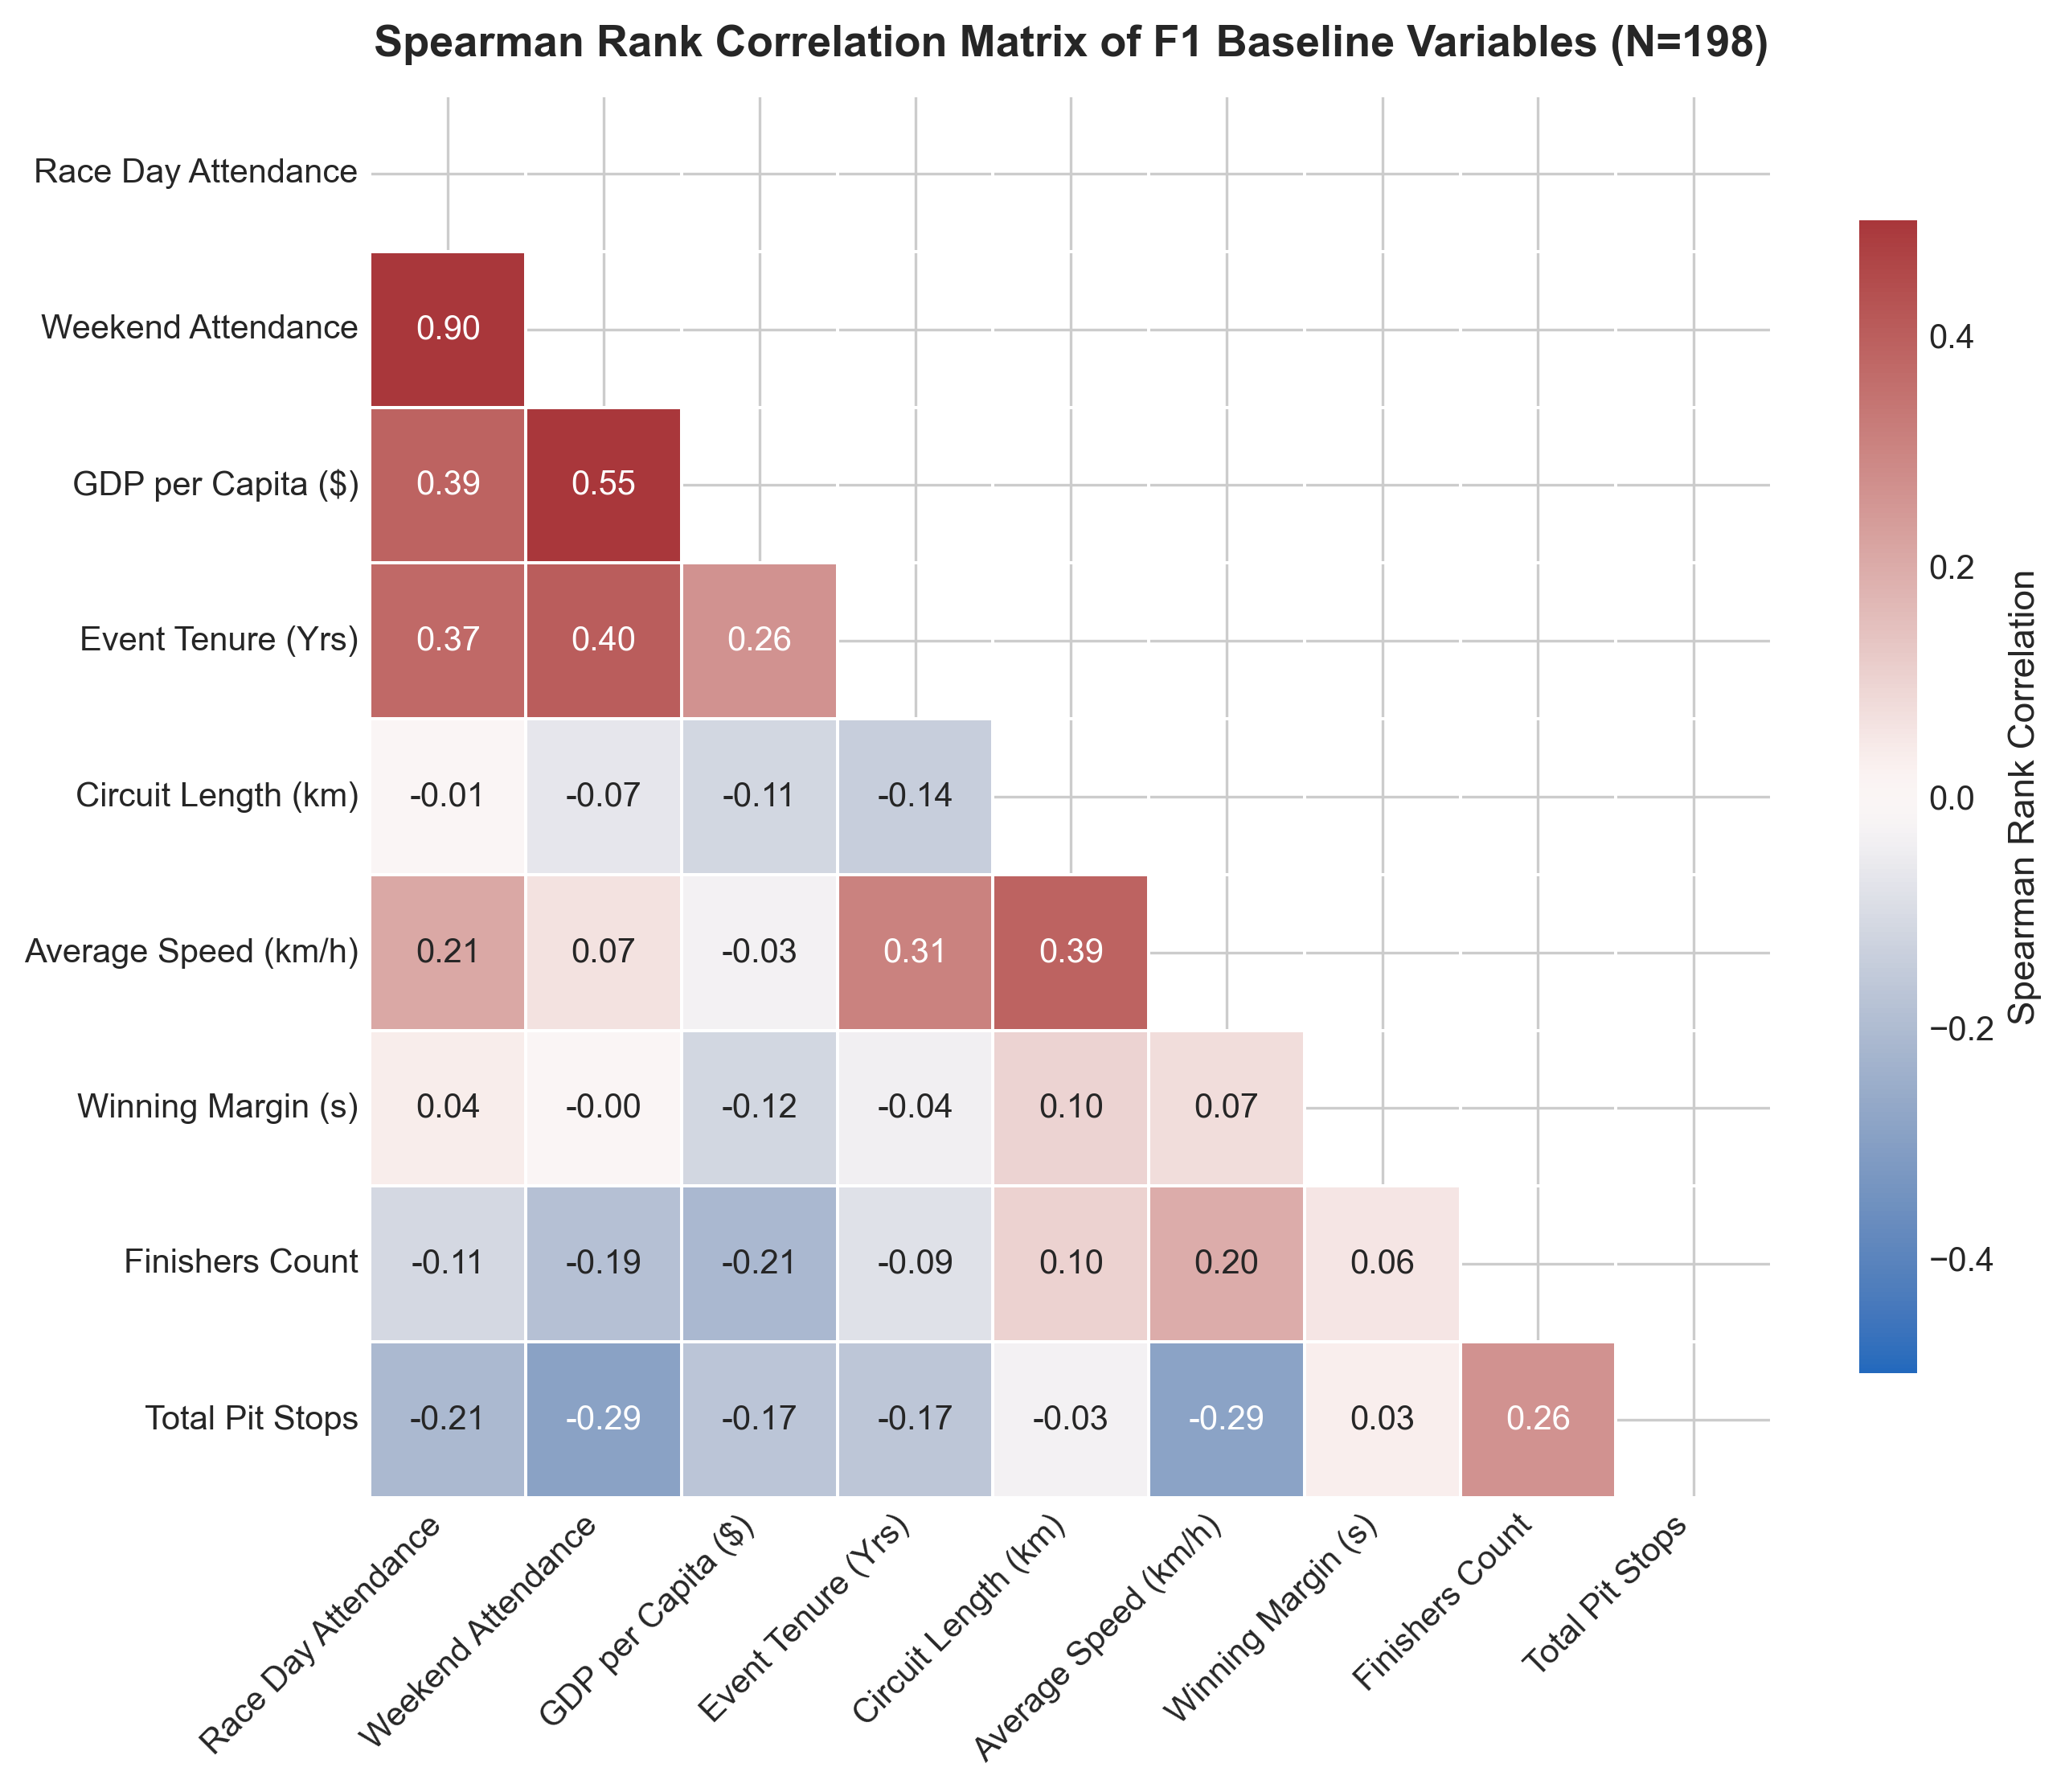

In [7]:
fig, ax = plt.subplots(figsize=(9, 7.5))
corr_vars = [
    'attendance_race_day', 'attendance_weekend', 'gdp_per_capita_usd',
    'event_tenure_years', 'circuit_length_km', 'average_speed_kmh',
    'winning_margin_s', 'finishers_count', 'total_pit_stops'
]
var_labels = [
    'Race Day Attendance', 'Weekend Attendance', 'GDP per Capita ($)',
    'Event Tenure (Yrs)', 'Circuit Length (km)', 'Average Speed (km/h)',
    'Winning Margin (s)', 'Finishers Count', 'Total Pit Stops'
]

corr_df = f1_clean[corr_vars]
corr_matrix = corr_df.corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='vlag', vmin=-0.5, vmax=0.5,
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Spearman Rank Correlation'},
            xticklabels=var_labels, yticklabels=var_labels, ax=ax)
ax.set_title('Spearman Rank Correlation Matrix of F1 Baseline Variables (N=198)', fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig('reports/figures/fig4_multivariate_correlation_matrix.png')
plt.show()

---
### Exhibit 5: Multidimensional Scatterplot: Attendance vs Host GDP per Capita (RQ3, RQ5)
**Analytical Question:** How does Buddh International Circuit position across host country economic wealth, event tenure, and crowd size?

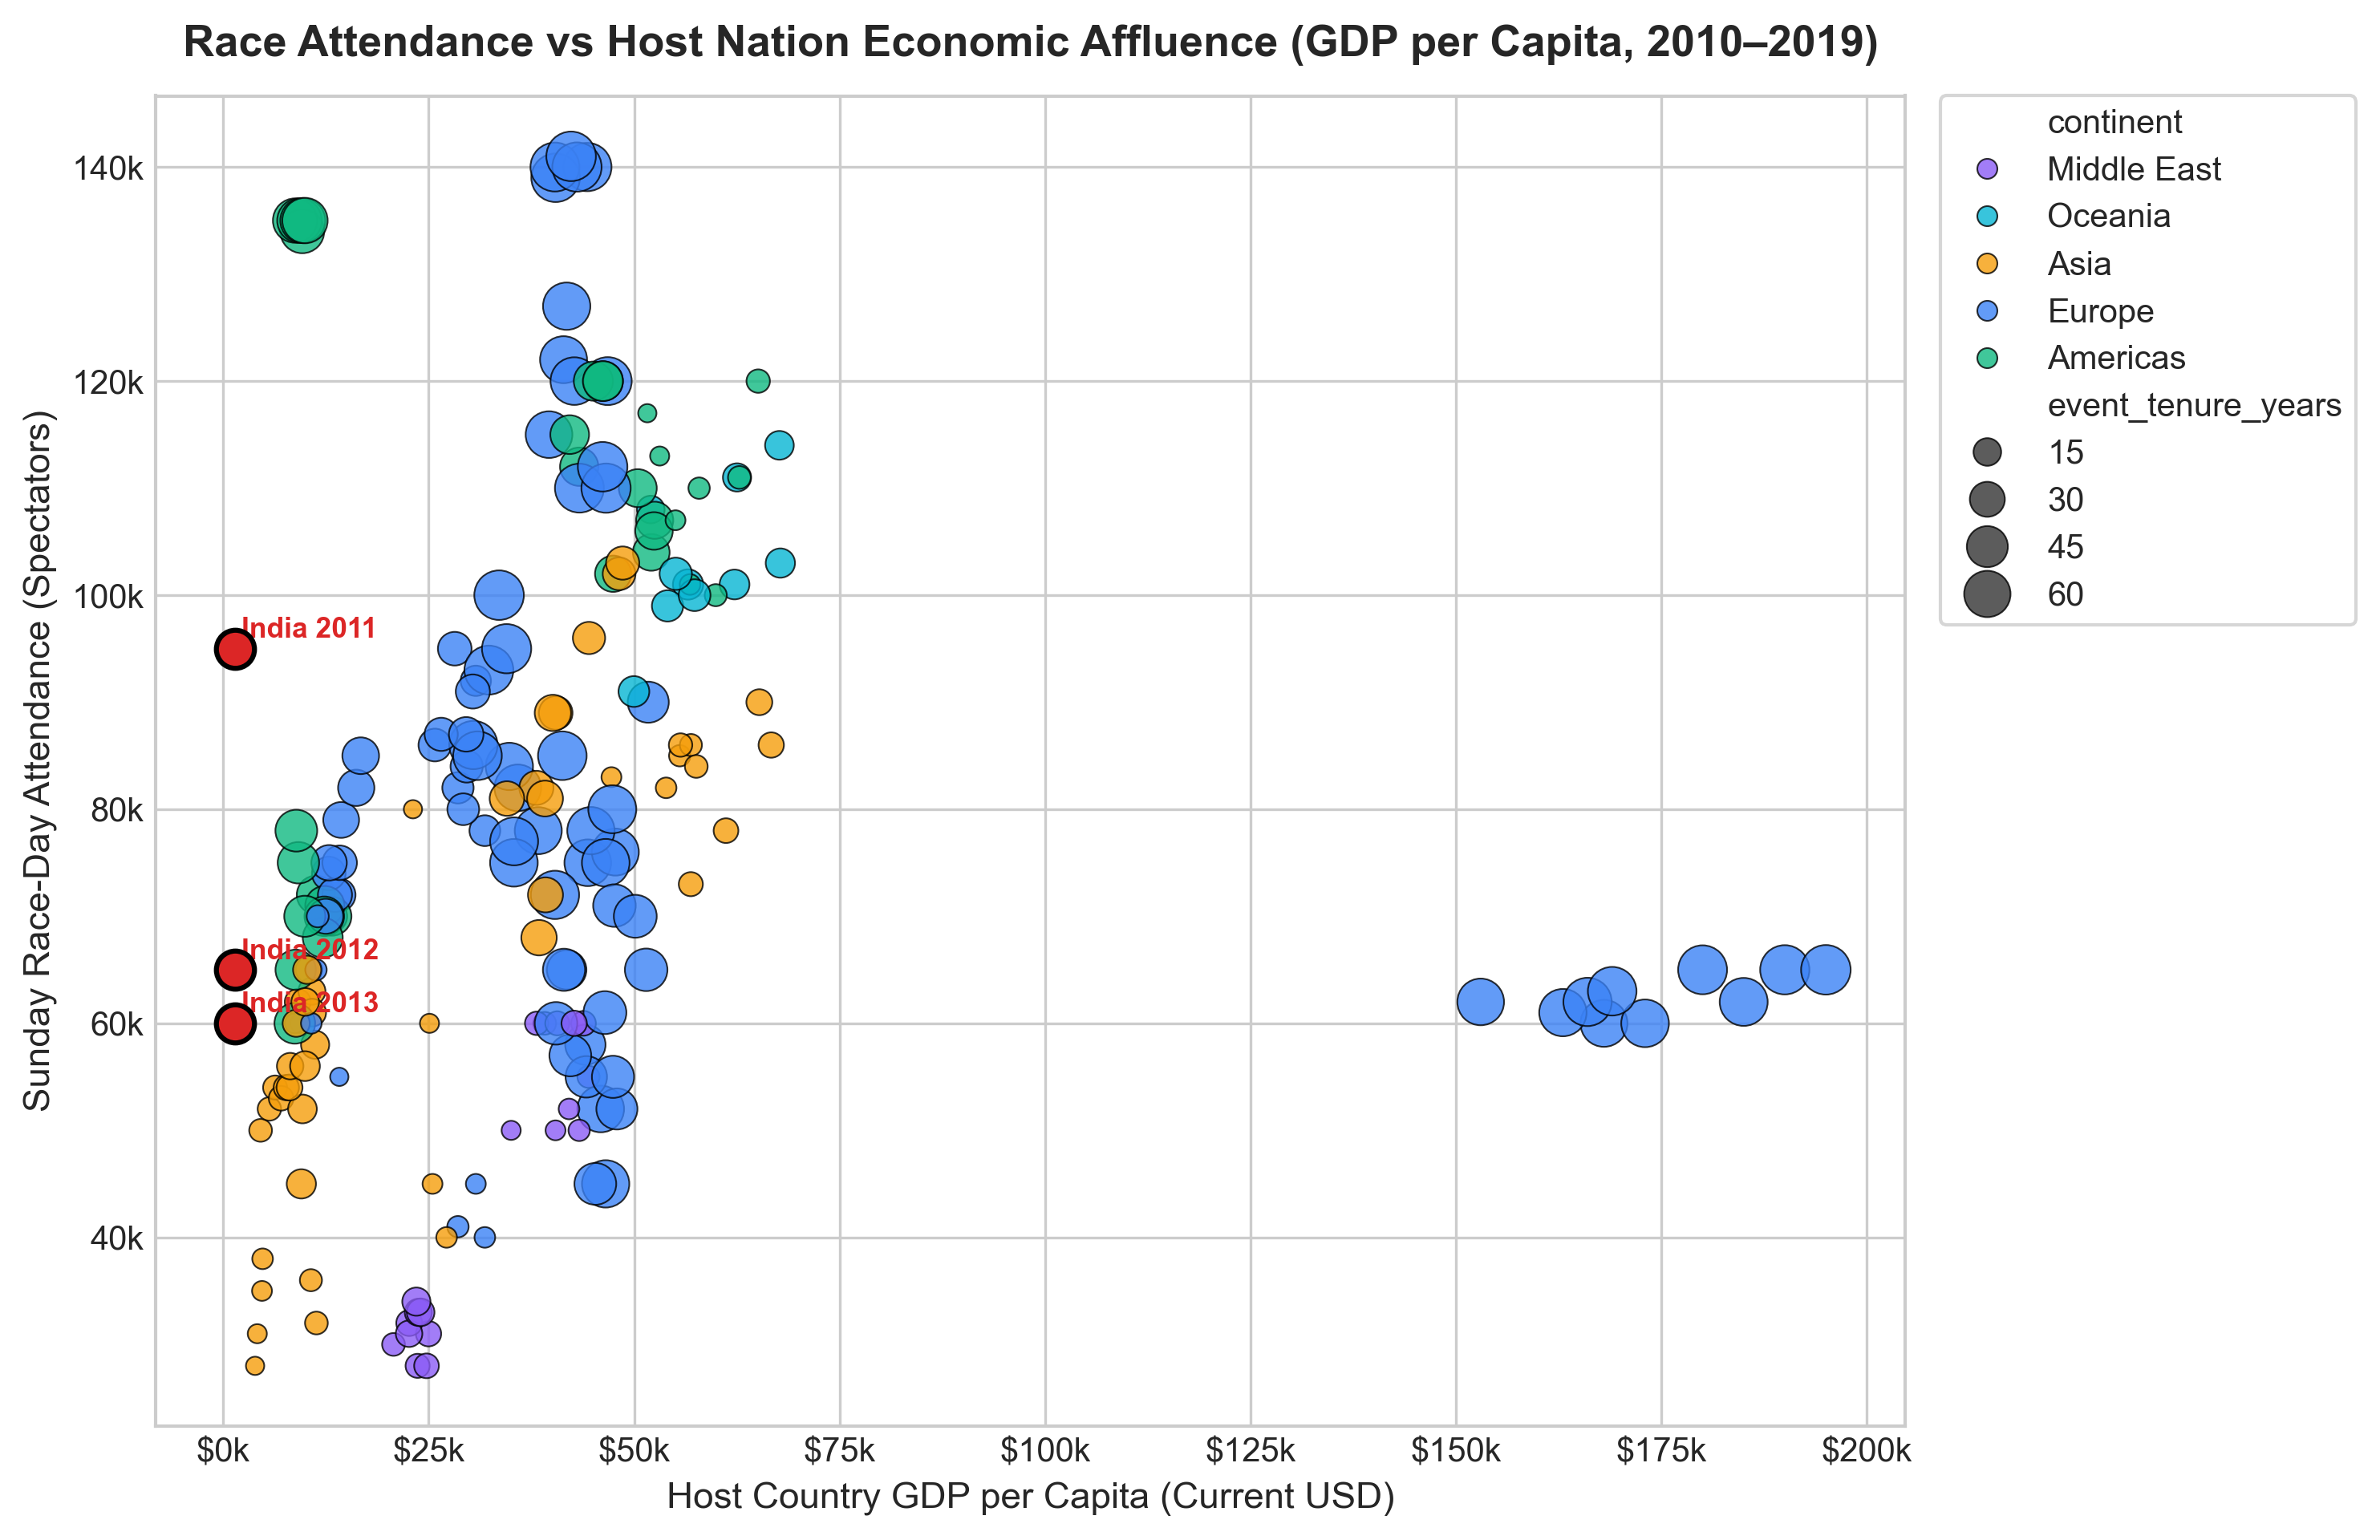

In [8]:
fig, ax = plt.subplots(figsize=(10, 6.5))
scatter = sns.scatterplot(
    data=f1_clean,
    x='gdp_per_capita_usd',
    y='attendance_race_day',
    hue='continent',
    size='event_tenure_years',
    sizes=(30, 220),
    palette=palette,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# Annotate India points
for _, r in buddh_points.iterrows():
    ax.scatter(r['gdp_per_capita_usd'], r['attendance_race_day'], color='#dc2626', s=130, zorder=6, edgecolors='black', linewidth=1.5)
    ax.text(r['gdp_per_capita_usd'] + 800, r['attendance_race_day'] + 1000, f"India {r['season']}", color='#dc2626', fontweight='bold', fontsize=8.5)
    
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))
ax.set_xlabel('Host Country GDP per Capita (Current USD)')
ax.set_ylabel('Sunday Race-Day Attendance (Spectators)')
ax.set_title('Race Attendance vs Host Nation Economic Affluence (GDP per Capita, 2010–2019)', fontweight='bold', pad=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, facecolor='white', borderaxespad=0)
plt.tight_layout()
fig.savefig('reports/figures/fig5_attendance_vs_gdp_multidimensional.png')
plt.show()

---
### Exhibit 6: Indian GP Commercial Squeeze & Promoter Operating Deficit (RQ4)
**Analytical Question:** How did escalating USD contract fees, INR exchange rate depreciation, and falling gate receipts create structural cash deficits?

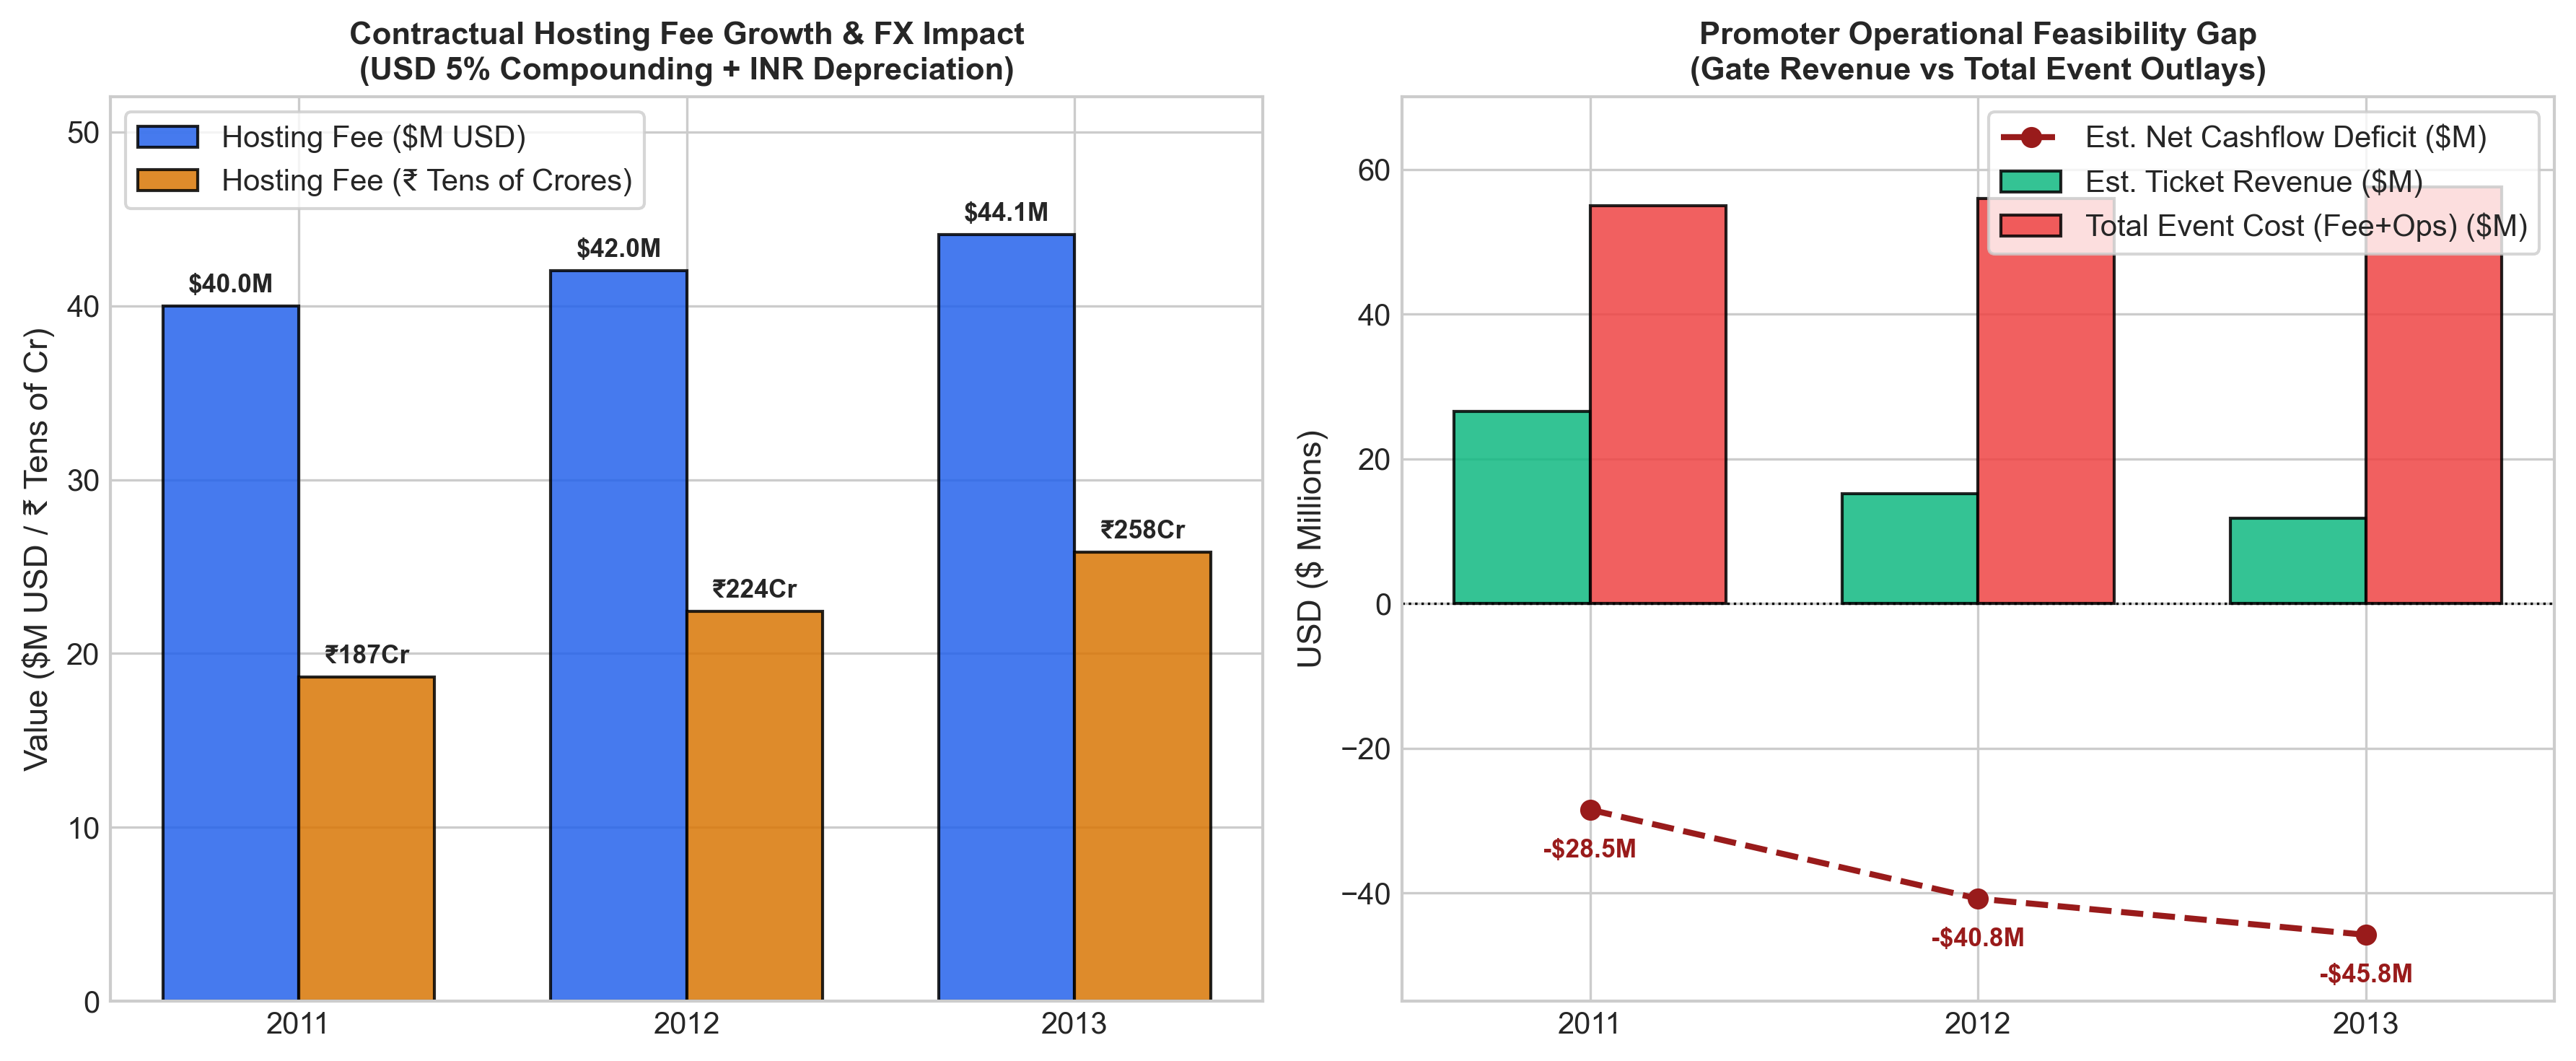

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Hosting Fee USD vs INR Crores
x = np.arange(len(years))
width = 0.35

rects1 = ax1.bar(x - width/2, india_eng['hosting_fee_usd_m'], width, label='Hosting Fee ($M USD)', color='#2563eb', alpha=0.85, edgecolor='black')
rects2 = ax1.bar(x + width/2, india_eng['hosting_fee_inr_crore'] / 10, width, label='Hosting Fee (₹ Tens of Crores)', color='#d97706', alpha=0.85, edgecolor='black')

ax1.set_ylabel('Value ($M USD / ₹ Tens of Cr)')
ax1.set_title('Contractual Hosting Fee Growth & FX Impact\n(USD 5% Compounding + INR Depreciation)', fontweight='bold', fontsize=10.5)
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend(loc='upper left', frameon=True, facecolor='white')

# Annotate values
for r in rects1:
    h = r.get_height()
    ax1.text(r.get_x() + r.get_width()/2., h + 0.5, f"${h:.1f}M", ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for r in rects2:
    h = r.get_height()
    ax1.text(r.get_x() + r.get_width()/2., h + 0.5, f"₹{h*10:.0f}Cr", ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax1.set_ylim(0, 52)

# Right: Revenue vs Total Cost vs Net Deficit
rects3 = ax2.bar(x - width/2, india_eng['estimated_ticket_revenue_usd_m'], width, label='Est. Ticket Revenue ($M)', color='#10b981', alpha=0.85, edgecolor='black')
rects4 = ax2.bar(x + width/2, india_eng['estimated_total_event_cost_usd_m'], width, label='Total Event Cost (Fee+Ops) ($M)', color='#ef4444', alpha=0.85, edgecolor='black')

ax2.plot(x, india_eng['estimated_net_operating_cashflow_usd_m'], color='#991b1b', marker='o', linewidth=2, linestyle='--', label='Est. Net Cashflow Deficit ($M)')

ax2.set_ylabel('USD ($ Millions)')
ax2.set_title('Promoter Operational Feasibility Gap\n(Gate Revenue vs Total Event Outlays)', fontweight='bold', fontsize=10.5)
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.legend(loc='upper right', frameon=True, facecolor='white')

for _, r in india_eng.iterrows():
    idx = r['season'] - 2011
    def_val = r['estimated_net_operating_cashflow_usd_m']
    ax2.text(idx, def_val - 4, f"-${abs(def_val):.1f}M", ha='center', va='top', color='#991b1b', fontweight='bold', fontsize=8.5)
    
ax2.set_ylim(-55, 70)
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.tight_layout()
fig.savefig('reports/figures/fig6_commercial_deficit_and_hosting_fee.png')
plt.show()

---
### Exhibit 7: Chronological Regulatory & Judicial Timeline (RQ6)
**Analytical Question:** How does the timeline untangle the 2013 operational exit from the retrospective 2017 Supreme Court Permanent Establishment ruling?

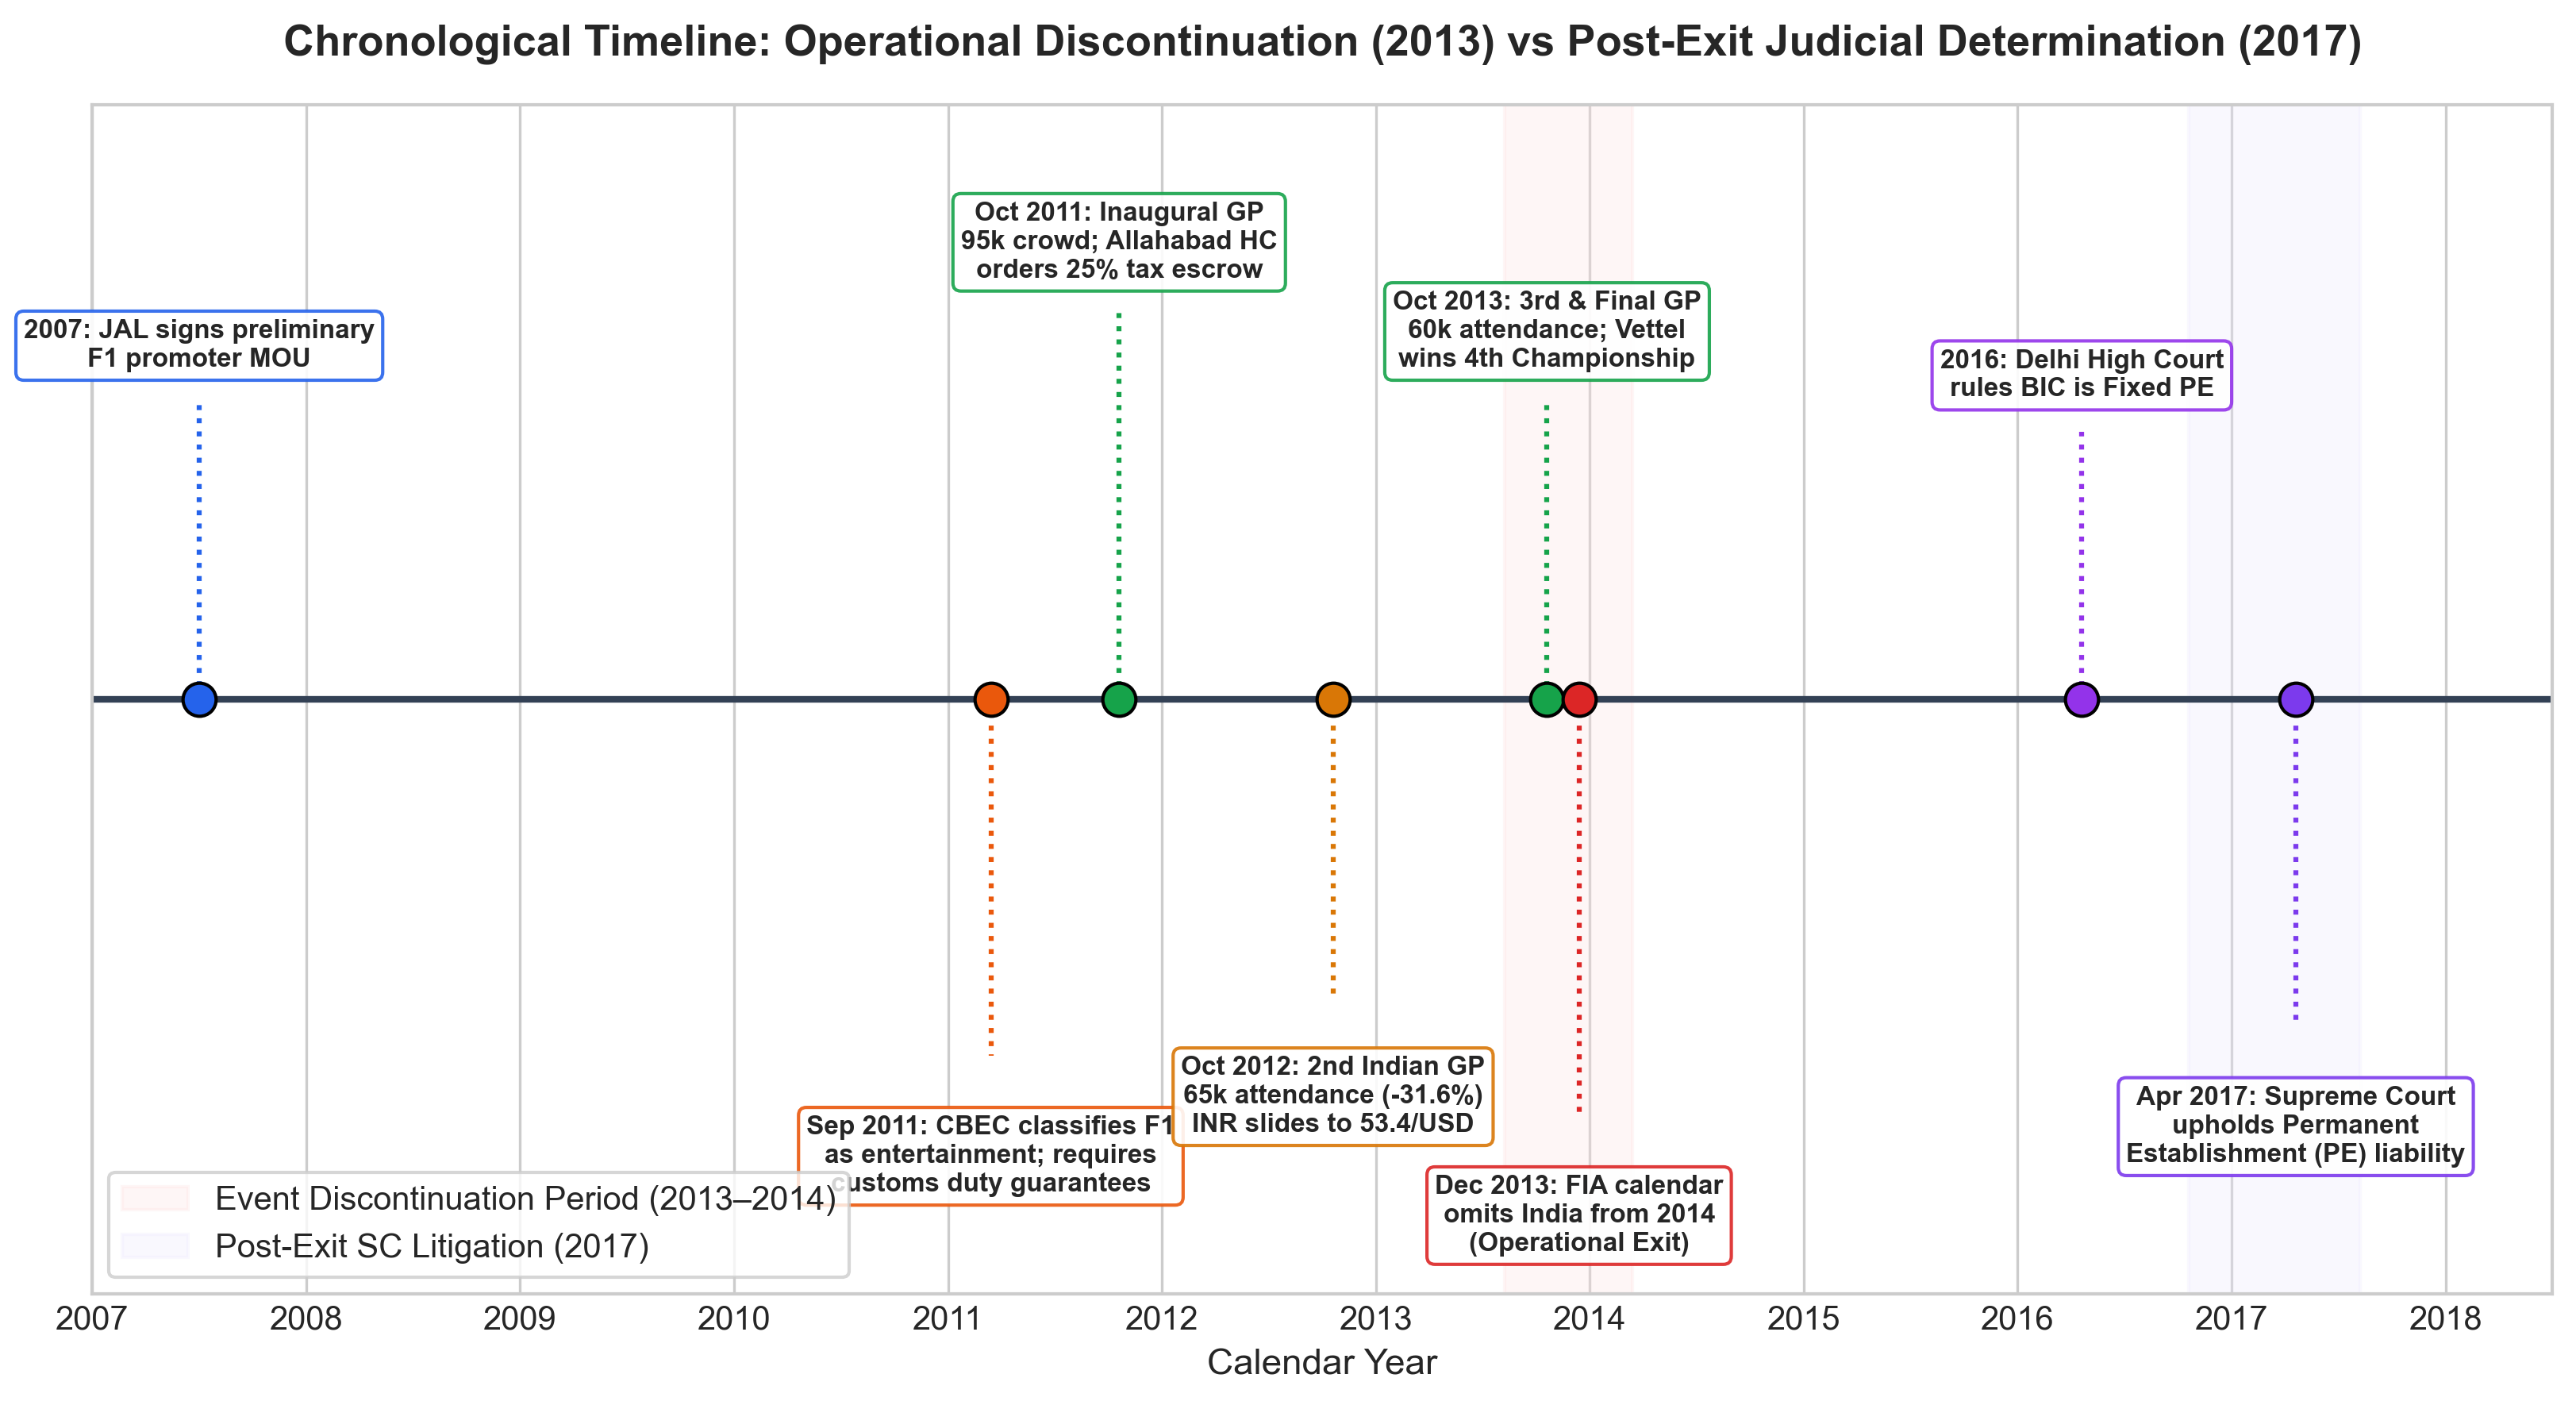

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

events = [
    (2007.5, '2007: JAL signs preliminary\nF1 promoter MOU', 'Contractual', '#2563eb', 1.0),
    (2011.2, 'Sep 2011: CBEC classifies F1\nas entertainment; requires\ncustoms duty guarantees', 'Regulatory', '#ea580c', -1.2),
    (2011.8, 'Oct 2011: Inaugural GP\n95k crowd; Allahabad HC\norders 25% tax escrow', 'Sporting/Legal', '#16a34a', 1.3),
    (2012.8, 'Oct 2012: 2nd Indian GP\n65k attendance (-31.6%)\nINR slides to 53.4/USD', 'Commercial', '#d97706', -1.0),
    (2013.8, 'Oct 2013: 3rd & Final GP\n60k attendance; Vettel\nwins 4th Championship', 'Sporting', '#16a34a', 1.0),
    (2013.95, 'Dec 2013: FIA calendar\nomits India from 2014\n(Operational Exit)', 'Operational Exit', '#dc2626', -1.4),
    (2016.3, '2016: Delhi High Court\nrules BIC is Fixed PE', 'Judicial', '#9333ea', 0.9),
    (2017.3, 'Apr 2017: Supreme Court\nupholds Permanent\nEstablishment (PE) liability', 'SC Judgment', '#7c3aed', -1.1)
]

# Draw timeline axis
ax.axhline(0, color='#334155', linewidth=2)
ax.set_xlim(2007, 2018.5)
ax.set_ylim(-2.0, 2.0)

for date, label, cat, col, y_pos in events:
    ax.scatter(date, 0, color=col, s=100, zorder=4, edgecolor='black')
    ax.vlines(date, 0, y_pos, color=col, linestyle=':', linewidth=1.5)
    ax.text(date, y_pos + (0.1 if y_pos > 0 else -0.2), label, ha='center', va='bottom' if y_pos > 0 else 'top',
            fontsize=8, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=col, alpha=0.9))
            
# Highlight operational exit vs SC ruling
ax.axvspan(2013.6, 2014.2, color='#fee2e2', alpha=0.3, label='Event Discontinuation Period (2013–2014)')
ax.axvspan(2016.8, 2017.6, color='#ede9fe', alpha=0.3, label='Post-Exit SC Litigation (2017)')

ax.set_xticks(range(2007, 2019))
ax.set_yticks([])
ax.set_xlabel('Calendar Year')
ax.set_title('Chronological Timeline: Operational Discontinuation (2013) vs Post-Exit Judicial Determination (2017)', fontweight='bold', pad=15)
ax.legend(loc='lower left', frameon=True, facecolor='white')
plt.tight_layout()
fig.savefig('reports/figures/fig7_historical_context_timeline.png')
plt.show()

---
### Exhibit 8: Circuit Characteristics & Speed Benchmark (RQ5)
**Analytical Question:** How did Buddh International Circuit rank in terms of average winning race speed compared to other circuits across 2010–2019?

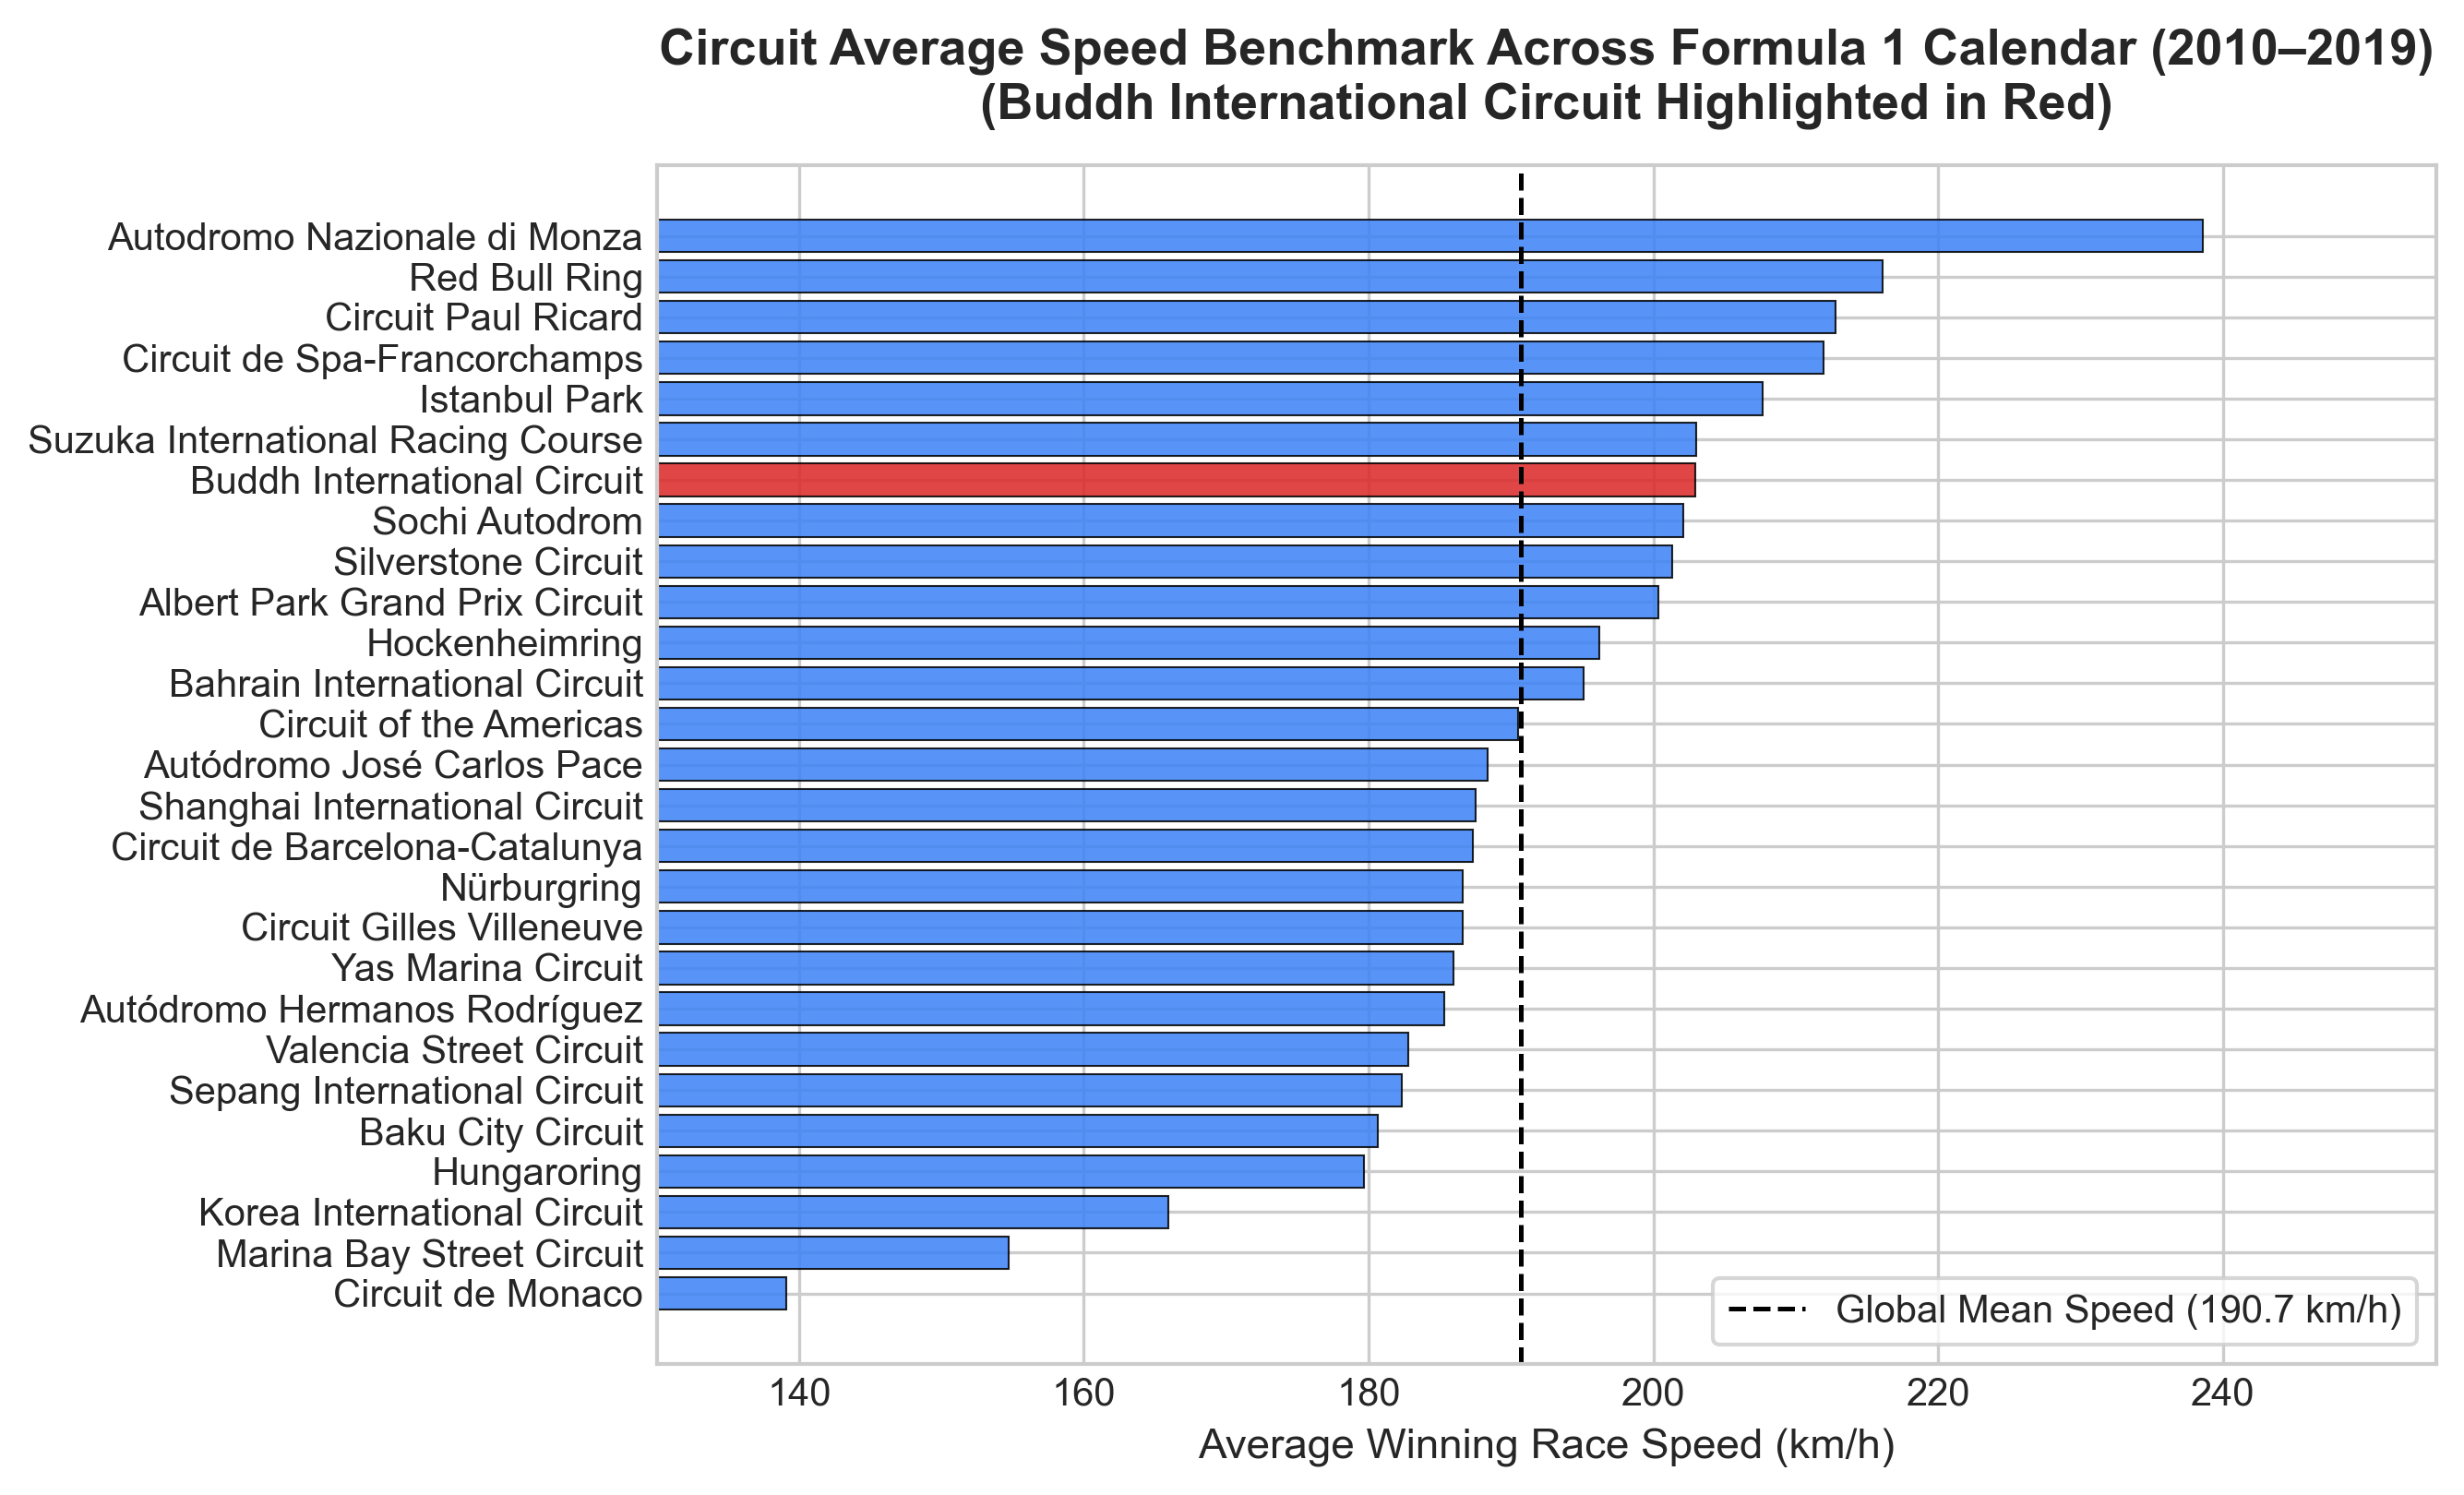

[OK] All 8 publication figures generated, displayed, and saved to reports/figures/.


In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))

circuit_speed = f1_clean.groupby(['circuit_id', 'circuit_name', 'circuit_type'])[['average_speed_kmh', 'circuit_length_km']].mean().reset_index()
circuit_speed = circuit_speed.sort_values(by='average_speed_kmh', ascending=False).reset_index(drop=True)

colors = ['#dc2626' if cid == 'buddh' else '#3b82f6' for cid in circuit_speed['circuit_id']]
bars = ax.barh(circuit_speed['circuit_name'], circuit_speed['average_speed_kmh'], color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)

ax.axvline(f1_clean['average_speed_kmh'].mean(), color='black', linestyle='--', linewidth=1.2, label=f"Global Mean Speed ({f1_clean['average_speed_kmh'].mean():.1f} km/h)")

ax.set_xlabel('Average Winning Race Speed (km/h)')
ax.set_title('Circuit Average Speed Benchmark Across Formula 1 Calendar (2010–2019)\n(Buddh International Circuit Highlighted in Red)', fontweight='bold', pad=12)
ax.set_xlim(130, 255)
ax.legend(loc='lower right', frameon=True, facecolor='white')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig('reports/figures/fig8_circuit_characteristics_radar_speed.png')
plt.show()

print("[OK] All 8 publication figures generated, displayed, and saved to reports/figures/.")